# 04 · PET: the numbers, the images, and what is realistic

**Goal.** Understand the PET data well enough to decide how PET should enter the model.

**Background in three lines.**
* **Amyloid PET** shows amyloid plaques, the earliest Alzheimer's change. It can be abnormal 15-20 years before symptoms.
* **Tau PET** shows tau tangles, which appear later and track symptoms much more closely.
* **FDG PET** shows glucose use; low uptake means neurons are not working well.

**"PET" is two different things in this project:**

1. **PET numbers**: tables in which the NACC PET core has already processed each scan into SUVRs and Centiloids. Thousands of people.
2. **PET images**: raw DICOM files on disk. 446 people.

This notebook looks at both and ends with a feasibility assessment. Only aggregates are shown.

In [1]:
import sys, warnings
sys.path.insert(0, "../scripts")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import nacc_utils as nu

warnings.filterwarnings("ignore")
nu.set_style()
amy, tau, fdg, img = nu.load_pet_amyloid(), nu.load_pet_tau(), nu.load_pet_fdg(), nu.load_pet_images()
uds = nu.clean(nu.load_uds(["NACCADC", "NACCUDSD", "CDRSUM", "CDRGLOB", "NACCNE4S", "NACCAGE", "NACCVNUM"]))
ids = set(uds.NACCID)
for name, d in [("Amyloid", amy), ("Tau", tau), ("FDG", fdg)]:
    print(f"{name}: {len(d):,} scans, {d.NACCID.nunique():,} participants, {d[d.NACCID.isin(ids)].NACCID.nunique():,} of them in the clinical table")

Amyloid: 6,168 scans, 5,412 participants, 5,100 of them in the clinical table
Tau: 3,324 scans, 2,934 participants, 2,724 of them in the clinical table
FDG: 885 scans, 639 participants, 600 of them in the clinical table


## 1. Where the PET numbers come from

Two programmes contribute:

* **SCAN** (2021 onward): centres follow one standard protocol. This is the higher-quality, harmonised source. It includes CLARiTI study scans.
* **Mixed protocol** (2005-2023): older scans that each centre acquired its own way, reprocessed centrally afterwards.

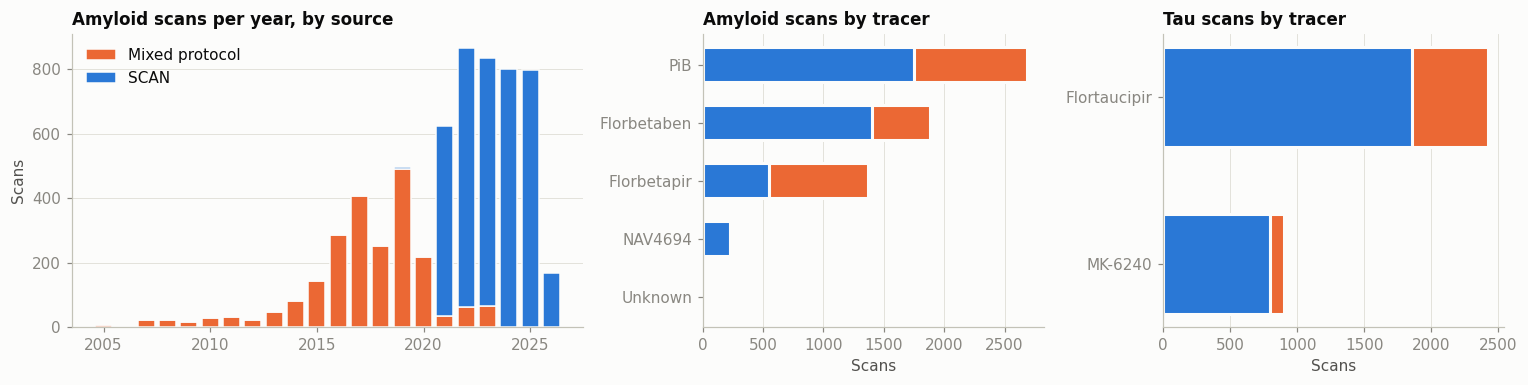

Scans per participant, amyloid: {1: 4748, 2: 583, 3: 71, 4: 9, 5: 1}


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), gridspec_kw={"width_ratios": [1.5, 1, 1]})
yr = pd.crosstab(amy.SCANDATE.dt.year, amy.source)[["Mixed protocol", "SCAN"]]
bottom = np.zeros(len(yr))
for col, color in zip(yr.columns, [nu.ORANGE, nu.BLUE]):
    axes[0].bar(yr.index, yr[col], bottom=bottom, color=color, label=col, edgecolor="#fcfcfb", linewidth=1); bottom += yr[col].values
axes[0].set_title("Amyloid scans per year, by source"); axes[0].legend(loc="upper left"); axes[0].set_ylabel("Scans")
for ax, d, title in [(axes[1], amy, "Amyloid scans by tracer"), (axes[2], tau, "Tau scans by tracer")]:
    tc = pd.crosstab(d.TRACER.map(nu.TRACERS).fillna("Unknown"), d.source).reindex(columns=["Mixed protocol", "SCAN"]).fillna(0)
    tc = tc.loc[tc.sum(axis=1).sort_values().index]
    ax.barh(tc.index, tc["SCAN"], color=nu.BLUE, height=0.6, edgecolor="#fcfcfb", linewidth=2)
    ax.barh(tc.index, tc["Mixed protocol"], left=tc["SCAN"], color=nu.ORANGE, height=0.6, edgecolor="#fcfcfb", linewidth=2)
    ax.set_title(title); ax.set_xlabel("Scans")
for ax in axes: ax.grid(axis="x" if ax is axes[0] else "y", visible=False)
fig.tight_layout(); nu.savefig(fig, "04_pet_sources"); plt.show()
print("Scans per participant, amyloid:", amy.groupby("NACCID").size().value_counts().sort_index().to_dict())

**Four amyloid tracers and two tau tracers are in use.** Different tracers bind differently, so their raw SUVR values are on different scales. The tables carry an explicit warning in every row: *"Use Centiloids (not SUVRs) to compare across tracers."* The next section shows why.

Most people have a single scan. PET is therefore a **snapshot** in this project, not a trajectory.

## 2. Amyloid: SUVR versus Centiloids

* **SUVR** (standardised uptake value ratio) = tracer signal in the cortex divided by signal in a reference region that should have no amyloid. About 1.0 means none.
* **Centiloid** = SUVR rescaled so that, for every tracer, 0 is the average of young healthy adults and 100 is the average of typical Alzheimer's dementia. It was designed precisely so that different tracers can be pooled.

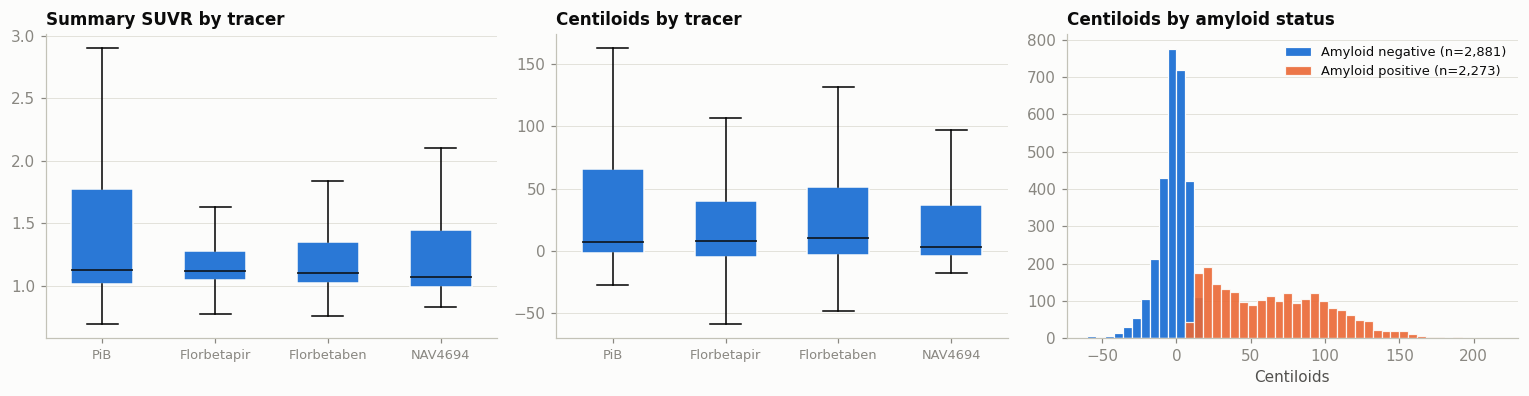

,Scans,With_Centiloids,With_status,% with Centiloids
Tracer,,,,
Florbetaben,1871,1680,1850,89.8
Florbetapir,1362,1359,1359,99.8
NAV4694,230,230,230,100.0
PiB,2673,1885,1885,70.5


In [3]:
a = amy[amy.QC == 1].copy(); a["Tracer"] = a.TRACER.map(nu.TRACERS)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.7))
order = ["PiB", "Florbetapir", "Florbetaben", "NAV4694"]
for ax, col, title in [(axes[0], "SUMMARY_SUVR", "Summary SUVR by tracer"), (axes[1], "CENTILOIDS", "Centiloids by tracer")]:
    data = [a.loc[a.Tracer == t, col].dropna() for t in order]
    bp = ax.boxplot(data, patch_artist=True, showfliers=False, widths=0.55, medianprops=dict(color=nu.INK))
    for patch in bp["boxes"]: patch.set(facecolor=nu.BLUE, edgecolor="#fcfcfb")
    ax.set_xticks(range(1, 5), order, fontsize=8.5); ax.set_title(title); ax.grid(axis="x", visible=False)
neg, pos = a[a.AMYLOID_STATUS == 0].CENTILOIDS.dropna(), a[a.AMYLOID_STATUS == 1].CENTILOIDS.dropna()
bins = np.arange(-60, 221, 6)
axes[2].hist(neg, bins=bins, color=nu.BLUE, label=f"Amyloid negative (n={len(neg):,})", edgecolor="#fcfcfb", linewidth=0.8)
axes[2].hist(pos, bins=bins, color=nu.ORANGE, label=f"Amyloid positive (n={len(pos):,})", edgecolor="#fcfcfb", linewidth=0.8, alpha=0.9)
axes[2].set_xlabel("Centiloids"); axes[2].set_title("Centiloids by amyloid status"); axes[2].legend(fontsize=8.5); axes[2].grid(axis="x", visible=False)
fig.tight_layout(); nu.savefig(fig, "04_amyloid_centiloids"); plt.show()
miss = a.groupby("Tracer").agg(Scans=("CENTILOIDS", "size"), With_Centiloids=("CENTILOIDS", "count"), With_status=("AMYLOID_STATUS", "count"))
miss["% with Centiloids"] = (miss.With_Centiloids / miss.Scans * 100).round(1)
miss

* SUVR levels differ by tracer (left); Centiloids line up (middle). **Use Centiloids as the amyloid feature.**
* The distribution is two humps: most people are clearly negative (around 0) or clearly positive (50-100). A simple positive/negative flag keeps most of the information.
* **Some scans have no Centiloid value** (see the table), mostly PiB scans. For those the SUVR exists but has not been converted. Either leave them missing, or use the positive/negative status where it exists. This is a small cleaning decision.

## 3. Linking a scan to a clinic visit

A scan has a date but no visit number. To use PET alongside clinical data we attach each person's first scan to their **nearest clinic visit**, and call that the **index visit**.

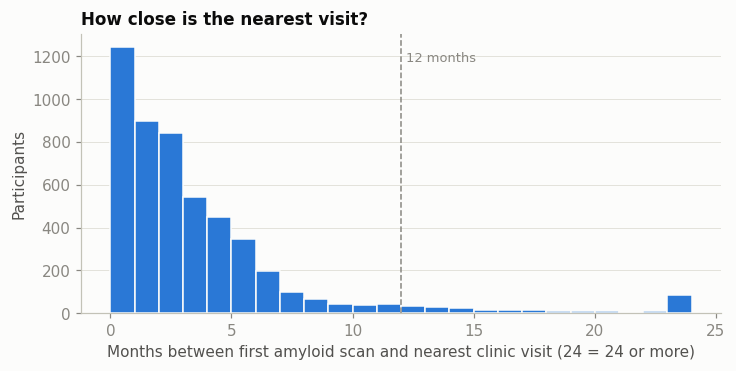

Within 6 months: 85.5%; within 12 months: 95.0%


In [4]:
idx = {"Amyloid numbers": nu.index_visit(amy[amy.QC == 1], uds), "Tau numbers": nu.index_visit(tau[tau.QC == 1], uds),
       "FDG numbers": nu.index_visit(fdg, uds), "Any image on disk": nu.index_visit(img, uds)}
gap_all = nu.index_visit(amy[amy.QC == 1], uds, window_days=100000).gap_days
fig, ax = plt.subplots(figsize=(7.5, 3.3))
ax.hist(gap_all.clip(upper=730) / 30.44, bins=np.arange(0, 25, 1), color=nu.BLUE, edgecolor="#fcfcfb", linewidth=1)
ax.axvline(12, color=nu.MUTED, ls="--", lw=1); ax.text(12.2, ax.get_ylim()[1] * 0.9, "12 months", color=nu.MUTED, fontsize=8.5)
ax.set_xlabel("Months between first amyloid scan and nearest clinic visit (24 = 24 or more)"); ax.set_ylabel("Participants")
ax.set_title("How close is the nearest visit?"); ax.grid(axis="x", visible=False); nu.savefig(fig, "04_scan_visit_gap"); plt.show()
print(f"Within 6 months: {nu.pct((gap_all <= 183).sum(), len(gap_all))}%; within 12 months: {nu.pct((gap_all <= 365).sum(), len(gap_all))}%")

Most scans have a visit within six months, and about 95% within a year. A 12-month window is a reasonable default. Amyloid changes slowly (a few Centiloids a year), so a scan and a visit a few months apart describe the same state.

**Leakage check.** If the scan was taken *after* the index visit, the model is technically using information from the future. For amyloid over a few months this is harmless in practice, but it should be stated. The strict alternative is to allow only scans on or before the index visit.

## 4. Who has PET?

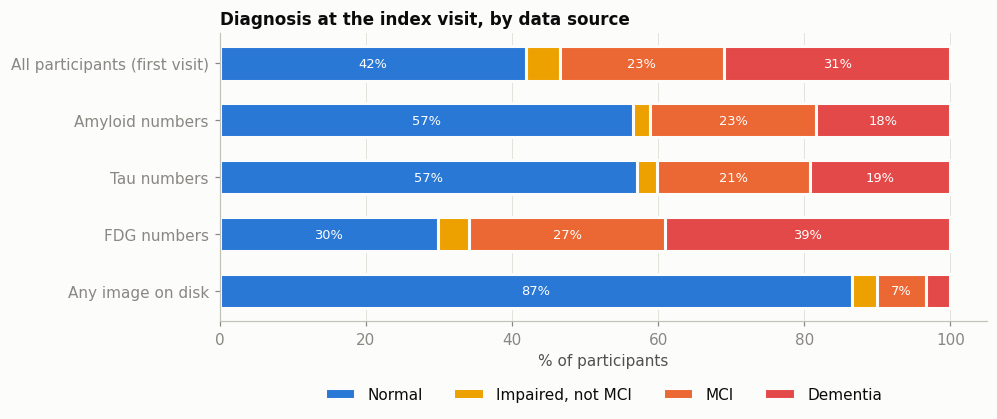

,Participants with an index visit,Centres,Median age,% APOE genotyped,% with at least one e4
Amyloid numbers,4816,36,71,85.2,39.6
Tau numbers,2558,32,71,87.4,39.7
FDG numbers,530,11,71,77.2,41.3
Any image on disk,446,23,72,100.0,31.4


In [5]:
comp = pd.DataFrame({k: v.i_NACCUDSD.map(nu.DX_LABELS).value_counts(normalize=True) * 100 for k, v in idx.items()})
allbase = uds[uds.NACCVNUM == 1].NACCUDSD.map(nu.DX_LABELS).value_counts(normalize=True) * 100
comp.insert(0, "All participants (first visit)", allbase)
comp = comp.reindex([nu.DX_LABELS[k] for k in [1, 2, 3, 4]])
fig, ax = plt.subplots(figsize=(9, 3.4))
left = np.zeros(comp.shape[1])
for k in [1, 2, 3, 4]:
    v = comp.loc[nu.DX_LABELS[k]].values
    ax.barh(comp.columns, v, left=left, color=nu.DX_COLORS[k], label=nu.DX_LABELS[k], edgecolor="#fcfcfb", linewidth=2, height=0.6)
    for y, (l, w) in enumerate(zip(left, v)):
        if w > 6: ax.text(l + w / 2, y, f"{w:.0f}%", ha="center", va="center", color="white", fontsize=8.5)
    left += v
ax.invert_yaxis(); ax.set_xlabel("% of participants"); ax.set_title("Diagnosis at the index visit, by data source")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.18)); ax.grid(axis="y", visible=False)
nu.savefig(fig, "04_pet_cohort_dx"); plt.show()
pd.DataFrame({k: {"Participants with an index visit": len(v), "Centres": v.i_NACCADC.nunique(), "Median age": v.i_NACCAGE.median(),
                  "% APOE genotyped": nu.pct(v.i_NACCNE4S.notna().sum(), len(v)), "% with at least one e4": nu.pct((v.i_NACCNE4S >= 1).sum(), v.i_NACCNE4S.notna().sum())}
              for k, v in idx.items()}).T.apply(lambda c: c.astype(int) if (c % 1 == 0).all() else c)

**People with PET are not like everyone else.** They are more often cognitively normal, because PET research studies mainly recruit people before or early in the disease. The image subset is the extreme case: the large majority are cognitively normal.

This has two consequences:
* a model trained on the PET subset describes PET volunteers, not all NACC participants;
* a group that is mostly healthy will have **few people who decline**, which limits what can be learned. Section 6 counts them.

## 5. Do the PET numbers carry signal?

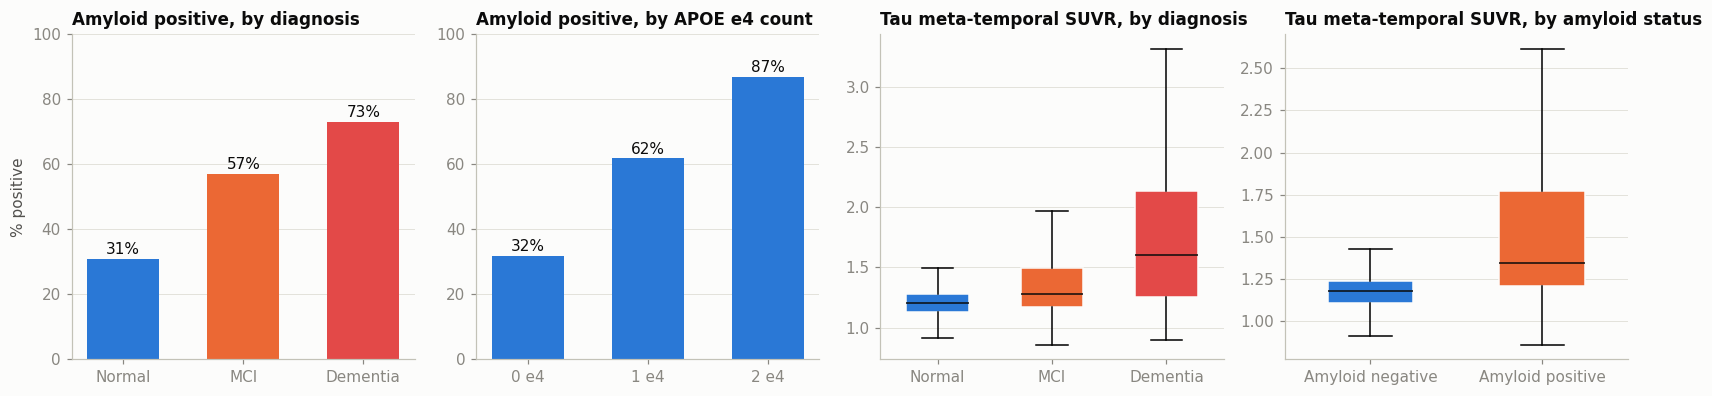

Spearman correlation at the index visit: Centiloids vs CDR-SB = 0.37 (n=4066); tau meta-temporal vs CDR-SB = 0.41 (n=2549)
Tau tracers: {'Flortaucipir': {'count': 1913, 'median': 1.26}, 'MK-6240': {'count': 636, 'median': 1.14}}


In [6]:
ai, ti = idx["Amyloid numbers"], idx["Tau numbers"]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.7))
pos_dx = ai.groupby("i_NACCUDSD").AMYLOID_STATUS.mean().reindex([1, 3, 4]) * 100
axes[0].bar([nu.DX_LABELS[k] for k in pos_dx.index], pos_dx.values, color=[nu.DX_COLORS[k] for k in pos_dx.index], width=0.6)
for i, v in enumerate(pos_dx.values): axes[0].text(i, v + 1.5, f"{v:.0f}%", ha="center")
axes[0].set_ylim(0, 100); axes[0].set_title("Amyloid positive, by diagnosis"); axes[0].set_ylabel("% positive")
pos_e4 = ai.groupby("i_NACCNE4S").AMYLOID_STATUS.mean() * 100
axes[1].bar([f"{int(k)} e4" for k in pos_e4.index], pos_e4.values, color=nu.BLUE, width=0.6)
for i, v in enumerate(pos_e4.values): axes[1].text(i, v + 1.5, f"{v:.0f}%", ha="center")
axes[1].set_ylim(0, 100); axes[1].set_title("Amyloid positive, by APOE e4 count")
data = [ti.loc[ti.i_NACCUDSD == k, "META_TEMPORAL_SUVR"].dropna() for k in [1, 3, 4]]
bp = axes[2].boxplot(data, patch_artist=True, showfliers=False, widths=0.55, medianprops=dict(color=nu.INK))
for patch, k in zip(bp["boxes"], [1, 3, 4]): patch.set(facecolor=nu.DX_COLORS[k], edgecolor="#fcfcfb")
axes[2].set_xticks([1, 2, 3], ["Normal", "MCI", "Dementia"]); axes[2].set_title("Tau meta-temporal SUVR, by diagnosis")
both = ti.merge(nu.first_scan(amy)[["NACCID", "AMYLOID_STATUS", "CENTILOIDS"]], on="NACCID").dropna(subset=["AMYLOID_STATUS"])
data = [both.loc[both.AMYLOID_STATUS == s, "META_TEMPORAL_SUVR"].dropna() for s in [0, 1]]
bp = axes[3].boxplot(data, patch_artist=True, showfliers=False, widths=0.5, medianprops=dict(color=nu.INK))
for patch, c in zip(bp["boxes"], [nu.BLUE, nu.ORANGE]): patch.set(facecolor=c, edgecolor="#fcfcfb")
axes[3].set_xticks([1, 2], ["Amyloid negative", "Amyloid positive"]); axes[3].set_title("Tau meta-temporal SUVR, by amyloid status")
for ax in axes: ax.grid(axis="x", visible=False)
fig.tight_layout(); nu.savefig(fig, "04_pet_signal"); plt.show()
print("Spearman correlation at the index visit: Centiloids vs CDR-SB = %.2f (n=%d); tau meta-temporal vs CDR-SB = %.2f (n=%d)" % (
    ai[["CENTILOIDS", "i_CDRSUM"]].corr(method="spearman").iloc[0, 1], ai[["CENTILOIDS", "i_CDRSUM"]].dropna().shape[0],
    ti[["META_TEMPORAL_SUVR", "i_CDRSUM"]].corr(method="spearman").iloc[0, 1], ti[["META_TEMPORAL_SUVR", "i_CDRSUM"]].dropna().shape[0]))
print("Tau tracers:", ti.groupby(ti.TRACER.map(nu.TRACERS)).META_TEMPORAL_SUVR.agg(["count", "median"]).round(2).to_dict("index"))

The PET numbers behave as the biology predicts, which is a good check on the data and on our linking:

* amyloid positivity rises from normal to MCI to dementia, and with each APOE e4 copy;
* a notable share of **cognitively normal** people are amyloid positive. This is the "preclinical" group, and it is where PET could genuinely add to prediction, because cognition has not yet declined;
* tau is higher in impaired groups and is elevated almost only in amyloid-positive people.

**Tau SUVR is not comparable between the two tau tracers** and there is no agreed Centiloid-style scale for tau in these tables. Options: z-score within tracer, include tracer as a feature, or restrict to one tracer. This is a decision for the PET cleaning step.

### 5.1 The regional values are highly redundant

Each scan comes with about 160 regional SUVRs. Are those 160 separate pieces of information?

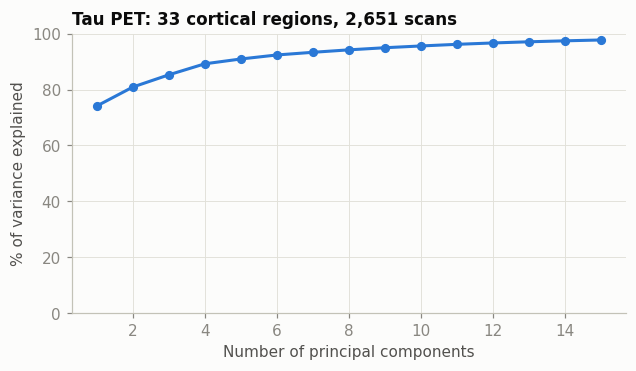

First component: 74% of variance; first 3: 85%; first 5: 91%


In [7]:
reg = pd.read_csv(nu.SCAN_DIR / "investigator_scan_clariti_taupetnpdka_nacc74.csv")
rcols = [c for c in reg.columns if c.startswith("CTX") and "LH" not in c and "RH" not in c and c.endswith("SUVR")]
Xr = reg.loc[reg.QCSTATUS == 1, rcols].dropna()
Xr = (Xr - Xr.mean()) / Xr.std()
eig = np.linalg.svd(Xr.values, compute_uv=False) ** 2
cum = np.cumsum(eig) / eig.sum() * 100
fig, ax = plt.subplots(figsize=(6.5, 3.3))
ax.plot(range(1, 16), cum[:15], marker="o", markersize=5, color=nu.BLUE)
ax.set_xlabel("Number of principal components"); ax.set_ylabel("% of variance explained"); ax.set_ylim(0, 100)
ax.set_title(f"Tau PET: {len(rcols)} cortical regions, {len(Xr):,} scans"); nu.savefig(fig, "04_tau_regions_pca"); plt.show()
print(f"First component: {cum[0]:.0f}% of variance; first 3: {cum[2]:.0f}%; first 5: {cum[4]:.0f}%")

A handful of components capture most of the variation. Feeding all 160 regions to a model with only a few hundred outcome events would invite overfitting. A defensible PET feature set is small: **Centiloids** (or amyloid status) for amyloid, and **meta-temporal SUVR** plus perhaps entorhinal SUVR for tau. These are the summaries used throughout the literature.

## 6. The key question: how many people decline after their scan?

A prediction model learns from **events**. A rough rule for stable models is at least 10 to 20 events per feature, and far more for deep learning. So we count, for each PET group: people with a clinic visit after the index visit, and how many of them declined.

In [8]:
sources = {"Amyloid numbers": amy[amy.QC == 1], "Tau numbers": tau[tau.QC == 1],
           "Amyloid and tau numbers": amy[(amy.QC == 1) & amy.NACCID.isin(tau.NACCID)],
           "Any image on disk": img, "Amyloid image on disk": img[img.folder_modality == "Amyloid"], "Tau image on disk": img[img.folder_modality == "Tau"]}
rows = {}
for name, s in sources.items():
    ix = nu.index_visit(s, uds)
    ev = nu.followup_events(ix, uds)
    nd = ev[ev.i_dx.isin([1, 2, 3])]
    rows[name] = {"With index visit": len(ix), "Not demented at index": int(ix.i_NACCUDSD.isin([1, 2, 3]).sum()),
                  "...with later follow-up": len(nd), "Median follow-up (years)": round(nd.followup_years.median(), 1),
                  "Followed 2+ years": int((nd.followup_years >= 2).sum()),
                  "Converted to dementia": int((nd.worst_dx == 4).sum()),
                  "Normal → MCI or dementia": int(((nd.i_dx.isin([1, 2])) & (nd.worst_dx >= 3)).sum()),
                  "CDR-SB rose by 1+": int((nd.max_cdrsb_increase >= 1).sum())}
events = pd.DataFrame(rows).T.apply(lambda c: c.astype(int) if (c % 1 == 0).all() else c)
events

,With index visit,Not demented at index,...with later follow-up,Median follow-up (years),Followed 2+ years,Converted to dementia,Normal → MCI or dementia,CDR-SB rose by 1+
Amyloid numbers,4816,3930,2752,2.7,1847,298,300,581
Tau numbers,2558,2065,1439,2.1,821,148,108,251
Amyloid and tau numbers,2203,1770,1273,2.4,804,133,97,244
Any image on disk,446,431,311,2.0,152,5,22,35
Amyloid image on disk,318,311,222,2.0,105,4,13,25
Tau image on disk,232,227,154,1.9,67,4,9,16


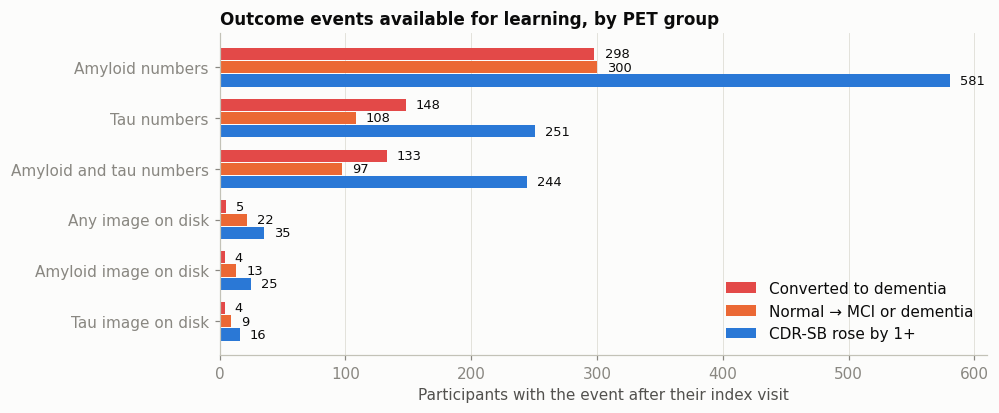

In [9]:
e = events[["Converted to dementia", "Normal → MCI or dementia", "CDR-SB rose by 1+"]]
fig, ax = plt.subplots(figsize=(9, 3.8))
ypos = np.arange(len(e))[::-1]
for i, (col, color) in enumerate(zip(e.columns, [nu.RED, nu.ORANGE, nu.BLUE])):
    ax.barh(ypos + (1 - i) * 0.26, e[col], height=0.24, color=color, label=col)
    for yv, v in zip(ypos, e[col]): ax.text(v + 8, yv + (1 - i) * 0.26, f"{v:,}", va="center", fontsize=8.5)
ax.set_yticks(ypos, e.index); ax.set_xlabel("Participants with the event after their index visit"); ax.grid(axis="y", visible=False)
ax.set_title("Outcome events available for learning, by PET group"); ax.legend(loc="lower right")
nu.savefig(fig, "04_events_by_pet_group"); plt.show()

**This table decides the PET strategy.**

* **PET numbers (thousands of people, hundreds of events).** Enough to train and test a tabular model with a small set of PET features, and enough to test honestly whether PET adds to the clinical model.
* **PET images (446 people).** Only a handful converted to dementia after their scan, and a few dozen show any CDR-SB rise. **That is not enough to train an image model to predict decline.** A 3D CNN has millions of parameters; with this few events it would memorise the training set and its test performance would be noise. No architecture choice fixes this. It is a property of the data, mainly because the image group is mostly healthy and was scanned recently.

Saying this plainly in the report is a strength, not a weakness: it shows the design followed the data.

## 7. The images themselves

What we know from the DICOM headers (from the data audit; nothing here needs the pixel data).

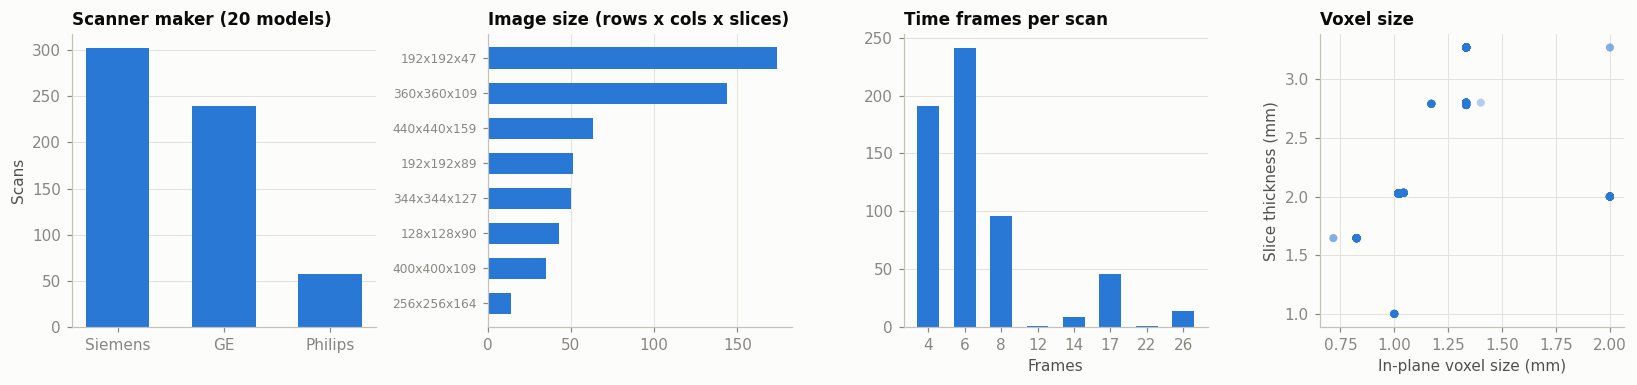

599 scans from 446 participants; modality: {'Amyloid': 318, 'Tau': 232, 'FDG': 49}
Units: {'BQML': 599}; series type: {'DYNAMIC/IMAGE': 599}
Amyloid images with a Centiloid value in the tables: 292 of 318; amyloid status: {'negative': 208, 'positive': 84}


In [10]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
man = img.manufacturer.str.title().str.replace("Ge Medical Systems", "GE").value_counts()
axes[0].bar(man.index, man.values, color=nu.BLUE, width=0.6); axes[0].set_title(f"Scanner maker ({img.scanner_model.nunique()} models)"); axes[0].set_ylabel("Scans")
mat = img.matrix.value_counts().head(8)
axes[1].barh(mat.index[::-1], mat.values[::-1], color=nu.BLUE, height=0.6); axes[1].set_title("Image size (rows x cols x slices)"); axes[1].tick_params(axis="y", labelsize=8)
fr = img.n_frames.value_counts().sort_index()
axes[2].bar(fr.index.astype(int).astype(str), fr.values, color=nu.BLUE, width=0.6); axes[2].set_title("Time frames per scan"); axes[2].set_xlabel("Frames")
axes[3].scatter(img.pixel_spacing_x, img.slice_thickness, s=28, color=nu.BLUE, alpha=0.35, edgecolor="none")
axes[3].set_xlabel("In-plane voxel size (mm)"); axes[3].set_ylabel("Slice thickness (mm)"); axes[3].set_title("Voxel size")
for ax in axes[:3]: ax.grid(axis="y" if ax is axes[1] else "x", visible=False)
fig.tight_layout(); nu.savefig(fig, "04_image_heterogeneity"); plt.show()
print(f"{len(img)} scans from {img.NACCID.nunique()} participants; modality: {img.folder_modality.value_counts().to_dict()}")
print(f"Units: {img.units.value_counts().to_dict()}; series type: {img.series_type.value_counts().to_dict()}")
m = img[img.folder_modality == "Amyloid"].merge(amy[["NACCID", "SCANDATE", "AMYLOID_STATUS", "CENTILOIDS"]], on=["NACCID", "SCANDATE"], how="left")
print(f"Amyloid images with a Centiloid value in the tables: {m.CENTILOIDS.notna().sum()} of {len(m)}; "
      f"amyloid status: {m.AMYLOID_STATUS.map({0: 'negative', 1: 'positive'}).value_counts().to_dict()}")

**What the images are.**

* **Raw scanner output**, in activity units (Bq/ml), not SUVR.
* **Dynamic**: each scan is 4 to 26 short time frames. They must be motion-corrected and averaged into one 3D image.
* **In each scanner's own space**, with many different image sizes and voxel sizes. They have not been registered to a standard brain template, and there is **no MRI on disk** to help with registration or to define brain regions.
* **Not normalised**: converting to SUVR needs a reference region (cerebellum), which first has to be located.

**What it would take to use them** (Phase 5 of the plan): DICOM to NIfTI conversion, frame averaging, registration to a PET template in standard space, reference-region scaling to SUVR, resampling to one grid, and visual QC. That is a real pipeline with established tools, and it is doable as a demonstration.

**What they can honestly be used for.**

1. **Reproducing the tables.** After preprocessing, compute a cortical SUVR from each image and compare it with the PET core's value for the same scan. Agreement shows the pipeline is correct. This is a good, checkable piece of work.
2. **An image model with a target that has enough labels**: predicting amyloid positive versus negative, or Centiloids, from the image. The labels exist for nearly every amyloid image. This demonstrates a 3D CNN and Grad-CAM on real data without pretending it predicts decline.
3. **An optional image embedding in the fusion model**, clearly labelled as exploratory, with the expectation that it adds little beyond the Centiloid number that the same image already produced.

What they cannot support is the claim "our 3D CNN predicts cognitive decline from PET images".

## 8. Which modalities does each person have?

The fusion model must cope with people who are missing whole modalities. This chart counts the combinations among people who are not demented at their first visit and have at least one follow-up visit (the pool a prediction cohort is drawn from).

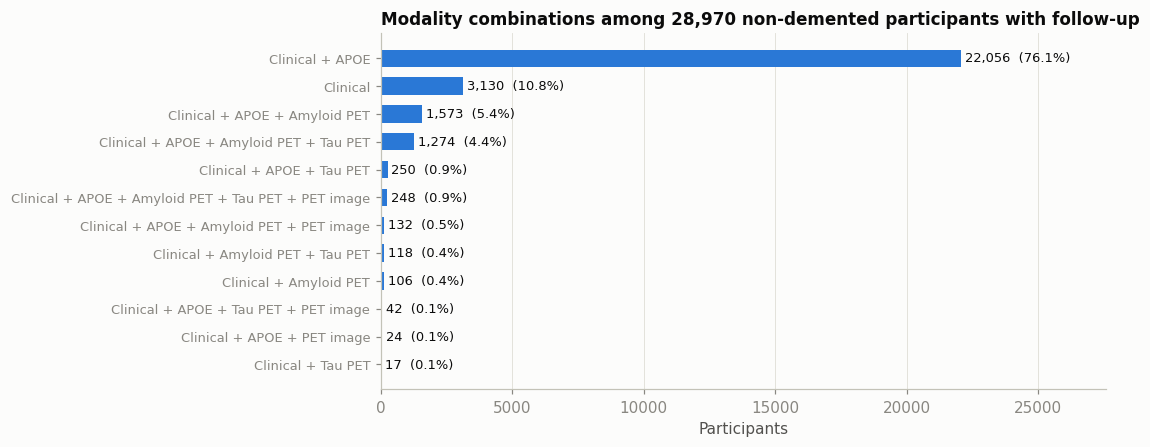

In [11]:
b = uds[uds.NACCVNUM == 1].set_index("NACCID")
nv = uds.groupby("NACCID").size()
pool = b.index[b.NACCUDSD.isin([1, 2, 3]) & (nv.reindex(b.index) >= 2)]
flags = pd.DataFrame({"APOE": b.loc[pool].NACCNE4S.notna().values, "Amyloid PET": pool.isin(amy.NACCID), "Tau PET": pool.isin(tau.NACCID),
                      "PET image": pool.isin(img.NACCID)}, index=pool)
combo = flags.apply(lambda r: " + ".join(["Clinical"] + [c for c in flags.columns if r[c]]), axis=1).value_counts()
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.barh(combo.index[::-1], combo.values[::-1], color=nu.BLUE, height=0.62)
for y, v in enumerate(combo.values[::-1]): ax.text(v + 150, y, f"{v:,}  ({nu.pct(v, len(pool))}%)", va="center", fontsize=8.5)
ax.set_xlim(0, combo.max() * 1.25); ax.set_xlabel("Participants"); ax.grid(axis="y", visible=False); ax.tick_params(axis="y", labelsize=8.5)
ax.set_title(f"Modality combinations among {len(pool):,} non-demented participants with follow-up")
nu.savefig(fig, "04_modality_combinations"); plt.show()

The large majority have clinical data and APOE but **no PET at all**. Complete data across every modality is the rare case.

This is the practical reason the project needs **missing-modality support**. If the model required every modality, it could be trained on only a small, unrepresentative group. The design that fits this picture is:

* a strong clinical model trained on everyone;
* PET added as an optional block, so that a person without PET still gets a prediction;
* an honest comparison, *on the people who have PET*, of the model with and without the PET block.

It is also what makes the planned clinician interface meaningful: the user ticks which modalities are available for a patient, and the model uses whatever is ticked.

## 9. Summary and decisions

**What we learned.**

* PET numbers: amyloid for about 5,100 linked participants, tau for about 2,700, FDG for about 600. Good quality, already processed, behave as biology predicts.
* Amyloid must be used as **Centiloids** (or status). Tau SUVR differs by tracer and needs handling.
* The 160 regional values are highly redundant; a few summary measures are enough.
* People with PET are healthier than the full cohort and were scanned recently, so follow-up after the scan is short (median about 2 to 2.5 years).
* PET images: 446 people, raw dynamic DICOM, about 20 scanner models, no MRI. Far too few outcome events to train an image model for decline.

**Decisions for the team.**

| # | Decision | Options | Suggested default |
|---|---|---|---|
| 1 | PET features | Summary measures only; or regional values too | Centiloids, amyloid status, tau meta-temporal SUVR, entorhinal SUVR |
| 2 | Tau across tracers | z-score within tracer; tracer as a feature; one tracer only | z-score within tracer, fitted on training data |
| 3 | Scan-to-visit window | 6 or 12 months; scans before the visit only, or either side | 12 months either side; strict version as a sensitivity check |
| 4 | Use mixed-protocol scans? | SCAN only (cleaner); or both (larger, longer follow-up) | Both, with source as a feature; SCAN-only as a check |
| 5 | Horizon for PET experiments | 2 or 3 years | 2 years, because follow-up after PET is short |
| 6 | Role of the images | Reproduce SUVR; amyloid-status CNN with Grad-CAM; exploratory embedding | All three are possible; none should be presented as predicting decline |
| 7 | FDG | Include or leave out | Leave out of the main model (few people, different population); mention as future work |